In [6]:
import os
import sys
import pickle
import dill
import numpy as np
import pandas as pd
import scipy
from scipy import stats
from scipy.stats import ranksums
# 绘图设置
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.pyplot import rc_context
import seaborn as sns
from statannotations.Annotator import Annotator
# 绘图字体 & 导出配置（论文级）
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['pdf.use14corefonts'] = False
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.sans-serif'] = ['Arial']
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.facecolor'] = 'white'
sns.set_style("white")
sns.set_context("paper")
plt.rcParams['axes.grid'] = False
# 单细胞分析
import anndata as ad
import scanpy as sc
import scanpy.external as sce
# 统计模型
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multitest import multipletests
import openpyxl
# Jupyter 专用
from IPython.display import display
from IPython.display import display, Markdown
%matplotlib inline
# 全局参数
os.chdir('/mnt/f/BTC_atlas_投稿/')
np.random.seed(34)
plt.rcParams['figure.figsize'] = [5, 5]
sc.set_figure_params(figsize=(5, 5))
color_clusters = sc.pl.palettes.default_102

In [4]:
input_dir = Path("./cogaps_input")
output_dir = Path("./cogaps_results")
output_dir.mkdir(parents=True, exist_ok=True)

groups = ["group1", "group2", "group3"]
ranks = range(10, 26)

n_iterations = 50000
seed = 42
n_threads = 48
RUN_ALL = False

In [7]:
os.chdir('/mnt/d/HCC_ICB/')

In [8]:
input_dir = Path("./cogaps_input")
output_dir = Path("./cogaps_results")
output_dir.mkdir(parents=True, exist_ok=True)

groups = ["group1", "group2", "group3"]
ranks = range(10, 26)

n_iterations = 50000
seed = 42
n_threads = 48
RUN_ALL = False

In [9]:
group1 = pd.read_csv(input_dir / "group1_input.txt", sep="\t", index_col=0)
group2 = pd.read_csv(input_dir / "group2_input.txt", sep="\t", index_col=0)
group3 = pd.read_csv(input_dir / "group3_input.txt", sep="\t", index_col=0)

print("group1:", group1.shape, group1.to_numpy().min(), group1.to_numpy().max())
print("group2:", group2.shape, group2.to_numpy().min(), group2.to_numpy().max())
print("group3:", group3.shape, group3.to_numpy().min(), group3.to_numpy().max())

print(group1.index.equals(group2.index))
print(group1.index.equals(group3.index))

group1: (8857, 82) 0.0 15.3689130672789
group2: (8857, 79) 0.0 17.3912303763283
group3: (8857, 291) 0.0 16.9272720194953
True
True


In [10]:
group1_adata = ad.AnnData(
    X=group1.to_numpy(dtype=np.float64),
    obs=pd.DataFrame(index=group1.index.astype(str)),
    var=pd.DataFrame(index=group1.columns.astype(str))
)

group2_adata = ad.AnnData(
    X=group2.to_numpy(dtype=np.float64),
    obs=pd.DataFrame(index=group2.index.astype(str)),
    var=pd.DataFrame(index=group2.columns.astype(str))
)

group3_adata = ad.AnnData(
    X=group3.to_numpy(dtype=np.float64),
    obs=pd.DataFrame(index=group3.index.astype(str)),
    var=pd.DataFrame(index=group3.columns.astype(str))
)

print(group1_adata)
print(group2_adata)
print(group3_adata)

AnnData object with n_obs × n_vars = 8857 × 82
AnnData object with n_obs × n_vars = 8857 × 79
AnnData object with n_obs × n_vars = 8857 × 291


In [16]:
group1_adata.write_h5ad("group1_input.h5ad")
group2_adata.write_h5ad("group2_input.h5ad")
group3_adata.write_h5ad("group3_input.h5ad")

In [17]:
from pathlib import Path

for f in [
    "group1_input.h5ad",
    "group2_input.h5ad",
    "group3_input.h5ad"
]:
    path = Path(f)
    print(path, path.exists(), f"{path.stat().st_size / 1024**2:.2f} MB")

group1_input.h5ad True 5.90 MB
group2_input.h5ad True 5.69 MB
group3_input.h5ad True 20.04 MB


In [ ]:
print("Python:", sys.version)
print("Platform:", platform.platform())
print("Logical CPUs:", os.cpu_count())


Python: 3.10.0 (default, Mar  3 2022, 09:58:08) [GCC 7.5.0]
Platform: Linux-5.10.16.3-microsoft-standard-WSL2-x86_64-with-glibc2.35
Logical CPUs: 60


In [2]:

import gc
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import anndata as ad
import torch
import matplotlib.pyplot as plt

from scipy import sparse
from scipy.optimize import linear_sum_assignment
from sklearn.metrics.pairwise import cosine_similarity
from torchnmf.nmf import NMF

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError(
        "当前 PyTorch 无法使用 CUDA。请安装 CUDA 版本的 PyTorch并确认 NVIDIA 驱动可用。"
    )

DEVICE = torch.device("cuda:0")
print("GPU:", torch.cuda.get_device_name(0))
print("GPU memory:", f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")


PyTorch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4090
GPU memory: 23.99 GB


In [12]:

# range 的右端不包含，因此这里是 K=10...25，共16个rank
K_VALUES = list(range(10, 26))

# 每个 K 的随机初始化次数：先用5测试，正式建议10–20
N_STARTS = 10

# 最大迭代次数；由每次实际返回的 n_iter 判断是否需要增加
MAX_ITER = 2000
TOL = 1e-5

# beta=2：Euclidean/Frobenius loss，适合连续的 log2(TPM+1)
BETA = 2

# 第一版不使用额外正则化
ALPHA = 0.0
L1_RATIO = 0.0

BASE_SEED = 42

# 在与最佳loss相差不超过1%的解中，优先选factor稳定性更高的解
LOSS_WINDOW = 0.01

OUTPUT_DIR = Path("cuda_nmf_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("K values:", K_VALUES)
print("Number of K:", len(K_VALUES))
print("Total factors per dataset:", sum(K_VALUES))


K values: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
Number of K: 16
Total factors per dataset: 280


In [13]:

def to_dense_float32(adata):
    X = adata.X
    if sparse.issparse(X):
        X = X.toarray()
    X = np.asarray(X, dtype=np.float32)

    if X.ndim != 2:
        raise ValueError("表达矩阵必须是二维矩阵。")
    if not np.isfinite(X).all():
        raise ValueError("表达矩阵包含 NaN 或 Inf。")
    if X.min() < 0:
        raise ValueError("NMF 输入不能含负值。")

    return np.ascontiguousarray(X)


def inspect_input(name, adata):
    X = to_dense_float32(adata)
    print("=" * 70)
    print("Dataset:", name)
    print("Shape (genes × samples):", X.shape)
    print("Minimum:", float(X.min()))
    print("Maximum:", float(X.max()))
    print("Mean:", float(X.mean()))
    print("Zero fraction:", f"{np.mean(X == 0):.2%}")
    print("Duplicated genes:", int(adata.obs_names.duplicated().sum()))
    print("Duplicated samples:", int(adata.var_names.duplicated().sum()))

    if adata.obs_names.duplicated().any():
        raise ValueError(f"{name} 中存在重复基因名。")
    if adata.var_names.duplicated().any():
        raise ValueError(f"{name} 中存在重复样本名。")

inspect_input("group1", group1_adata)
inspect_input("group2", group2_adata)
inspect_input("group3", group3_adata)


Dataset: group1
Shape (genes × samples): (8857, 82)
Minimum: 0.0
Maximum: 15.368912696838379
Mean: 3.4211854934692383
Zero fraction: 2.06%
Duplicated genes: 0
Duplicated samples: 0
Dataset: group2
Shape (genes × samples): (8857, 79)
Minimum: 0.0
Maximum: 17.3912296295166
Mean: 3.4372165203094482
Zero fraction: 2.36%
Duplicated genes: 0
Duplicated samples: 0
Dataset: group3
Shape (genes × samples): (8857, 291)
Minimum: 0.0
Maximum: 16.92727279663086
Mean: 3.2634780406951904
Zero fraction: 1.66%
Duplicated genes: 0
Duplicated samples: 0


In [14]:

print("group1 vs group2 same ordered genes:", group1_adata.obs_names.equals(group2_adata.obs_names))
print("group1 vs group3 same ordered genes:", group1_adata.obs_names.equals(group3_adata.obs_names))

common_genes = (
    group1_adata.obs_names
    .intersection(group2_adata.obs_names)
    .intersection(group3_adata.obs_names)
)

print("Common genes:", len(common_genes))
print("group1 genes:", group1_adata.n_obs)
print("group2 genes:", group2_adata.n_obs)
print("group3 genes:", group3_adata.n_obs)


group1 vs group2 same ordered genes: True
group1 vs group3 same ordered genes: True
Common genes: 8857
group1 genes: 8857
group2 genes: 8857
group3 genes: 8857


In [15]:

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


@torch.no_grad()
def reconstruction_metrics(V, model):
    reconstructed = model()
    residual = V - reconstructed
    rss = torch.sum(residual ** 2)
    x_ss = torch.sum(V ** 2)

    relative_frobenius_error = torch.sqrt(rss / x_ss.clamp_min(1e-12))
    explained_variance_like = 1.0 - rss / x_ss.clamp_min(1e-12)

    return {
        "rss": float(rss.detach().cpu()),
        "relative_frobenius_error": float(relative_frobenius_error.detach().cpu()),
        "explained_variance_like": float(explained_variance_like.detach().cpu()),
    }


def run_one_nmf_start(
    adata,
    k,
    seed,
    max_iter=MAX_ITER,
    tol=TOL,
    beta=BETA,
    alpha=ALPHA,
    l1_ratio=L1_RATIO,
    verbose=False,
):
    X = to_dense_float32(adata)

    # torchnmf 输入：samples × genes
    V = torch.as_tensor(X.T, dtype=torch.float32, device=DEVICE)

    set_all_seeds(seed)
    model = NMF(V.shape, rank=k).to(DEVICE)

    start = time.time()
    n_iter = model.fit(
        V,
        beta=beta,
        tol=tol,
        max_iter=max_iter,
        verbose=verbose,
        alpha=alpha,
        l1_ratio=l1_ratio,
    )
    torch.cuda.synchronize()

    metrics = reconstruction_metrics(V, model)

    # W：genes × K，即A
    A = model.W.detach().cpu().numpy().astype(np.float32, copy=True)

    # H：samples × K；数学P为K × samples
    H_samples = model.H.detach().cpu().numpy().astype(np.float32, copy=True)

    elapsed = time.time() - start

    del model, V
    torch.cuda.empty_cache()
    gc.collect()

    return {
        "A": A,
        "H_samples": H_samples,
        "n_iter": int(n_iter),
        "seconds": float(elapsed),
        "seed": int(seed),
        **metrics,
    }


In [16]:

def l2_normalize_columns(matrix, eps=1e-12):
    norms = np.linalg.norm(matrix, axis=0, keepdims=True)
    return matrix / np.maximum(norms, eps)


def match_factors(reference_A, query_A):
    reference_norm = l2_normalize_columns(reference_A)
    query_norm = l2_normalize_columns(query_A)
    similarity = reference_norm.T @ query_norm

    # Hungarian matching：最大化一一对应的cosine similarity
    row_ind, col_ind = linear_sum_assignment(-similarity)

    order = np.empty(reference_A.shape[1], dtype=int)
    order[row_ind] = col_ind
    matched_similarity = similarity[row_ind, col_ind]

    return {
        "order": order,
        "matched_similarity": matched_similarity,
        "mean_similarity": float(np.mean(matched_similarity)),
        "min_similarity": float(np.min(matched_similarity)),
    }


def reorder_result_factors(result, order):
    result = result.copy()
    result["A"] = result["A"][:, order]
    result["H_samples"] = result["H_samples"][:, order]
    return result


In [17]:

def run_multi_start_cuda_nmf(
    group_name,
    adata,
    k,
    n_starts=N_STARTS,
    max_iter=MAX_ITER,
    tol=TOL,
    beta=BETA,
    alpha=ALPHA,
    l1_ratio=L1_RATIO,
    base_seed=BASE_SEED,
    loss_window=LOSS_WINDOW,
    verbose_fit=False,
):
    all_results = []
    summary_rows = []
    total_start = time.time()

    for start_index in range(n_starts):
        seed = base_seed + k * 10_000 + start_index
        print(f"{group_name} | K={k} | start {start_index + 1}/{n_starts} | seed={seed}")

        result = run_one_nmf_start(
            adata=adata,
            k=k,
            seed=seed,
            max_iter=max_iter,
            tol=tol,
            beta=beta,
            alpha=alpha,
            l1_ratio=l1_ratio,
            verbose=verbose_fit,
        )

        result["start_index"] = start_index + 1
        all_results.append(result)
        summary_rows.append({
            "group": group_name,
            "K": k,
            "start": start_index + 1,
            "seed": seed,
            "n_iter": result["n_iter"],
            "seconds": result["seconds"],
            "rss": result["rss"],
            "relative_frobenius_error": result["relative_frobenius_error"],
            "explained_variance_like": result["explained_variance_like"],
        })

        print(
            f"  error={result['relative_frobenius_error']:.7f} | "
            f"n_iter={result['n_iter']} | time={result['seconds']:.2f}s"
        )

    summary = pd.DataFrame(summary_rows)
    best_loss_index = int(summary["relative_frobenius_error"].idxmin())
    reference = all_results[best_loss_index]

    mean_similarities = []
    min_similarities = []
    matched_results = []

    for result in all_results:
        match = match_factors(reference["A"], result["A"])
        matched_results.append(reorder_result_factors(result, match["order"]))
        mean_similarities.append(match["mean_similarity"])
        min_similarities.append(match["min_similarity"])

    summary["mean_factor_similarity_to_best_loss"] = mean_similarities
    summary["min_factor_similarity_to_best_loss"] = min_similarities

    best_error = summary["relative_frobenius_error"].min()
    cutoff = best_error * (1.0 + loss_window)
    candidates = summary.loc[
        summary["relative_frobenius_error"] <= cutoff
    ].copy()

    candidates = candidates.sort_values(
        ["mean_factor_similarity_to_best_loss", "relative_frobenius_error"],
        ascending=[False, True],
    )

    selected_index = int(candidates.index[0])
    selected_result = matched_results[selected_index]

    selected_result["selection_reference_start"] = int(summary.loc[best_loss_index, "start"])
    selected_result["selected_start"] = int(summary.loc[selected_index, "start"])
    selected_result["mean_factor_similarity_to_best_loss"] = float(
        summary.loc[selected_index, "mean_factor_similarity_to_best_loss"]
    )
    selected_result["min_factor_similarity_to_best_loss"] = float(
        summary.loc[selected_index, "min_factor_similarity_to_best_loss"]
    )

    summary["selected"] = False
    summary.loc[selected_index, "selected"] = True

    print("-" * 70)
    print(
        f"Selected start={selected_result['selected_start']} | "
        f"seed={selected_result['seed']} | "
        f"error={selected_result['relative_frobenius_error']:.7f} | "
        f"mean stability={selected_result['mean_factor_similarity_to_best_loss']:.4f}"
    )
    print(f"Total multi-start time: {time.time() - total_start:.2f}s")

    return selected_result, summary


In [18]:

def scale_A_by_gene(A):
    row_sums = A.sum(axis=1)
    return A.div(row_sums.replace(0, np.nan), axis=0).fillna(0)


def save_nmf_result(group_name, adata, k, selected_result, run_summary):
    group_dir = OUTPUT_DIR / group_name / f"k{k}"
    group_dir.mkdir(parents=True, exist_ok=True)

    pattern_names = [f"Pattern{i}" for i in range(1, k + 1)]

    A = pd.DataFrame(
        selected_result["A"],
        index=adata.obs_names.copy(),
        columns=pattern_names,
    )

    P_samples = pd.DataFrame(
        selected_result["H_samples"],
        index=adata.var_names.copy(),
        columns=pattern_names,
    )

    A_scaled = scale_A_by_gene(A)
    A_scaled.columns = [f"{group_name}_k{k}_{pattern}" for pattern in pattern_names]

    A_file = group_dir / f"{group_name}_k{k}_A.tsv"
    P_file = group_dir / f"{group_name}_k{k}_P_samples.tsv"
    Ascaled_file = group_dir / f"{group_name}_k{k}_Ascaled.tsv"
    runs_file = group_dir / f"{group_name}_k{k}_run_summary.tsv"
    result_file = group_dir / f"{group_name}_k{k}_cuda_nmf.h5ad"
    metadata_file = group_dir / f"{group_name}_k{k}_metadata.json"

    temp_A = group_dir / f"{group_name}_k{k}_A.tmp.tsv"
    temp_P = group_dir / f"{group_name}_k{k}_P_samples.tmp.tsv"
    temp_Ascaled = group_dir / f"{group_name}_k{k}_Ascaled.tmp.tsv"
    temp_runs = group_dir / f"{group_name}_k{k}_run_summary.tmp.tsv"
    temp_result = group_dir / f"{group_name}_k{k}_cuda_nmf.tmp.h5ad"

    A.to_csv(temp_A, sep="	")
    P_samples.to_csv(temp_P, sep="	")
    A_scaled.to_csv(temp_Ascaled, sep="	")
    run_summary.to_csv(temp_runs, sep="	", index=False)

    result_adata = ad.AnnData(
        X=to_dense_float32(adata),
        obs=A.copy(),
        var=P_samples.copy(),
    )

    result_adata.uns["algorithm"] = "torchnmf CUDA NMF, beta multiplicative updates"
    result_adata.uns["beta"] = BETA
    result_adata.uns["K"] = k
    result_adata.uns["seed"] = selected_result["seed"]
    result_adata.uns["n_iter"] = selected_result["n_iter"]
    result_adata.uns["rss"] = selected_result["rss"]
    result_adata.uns["relative_frobenius_error"] = selected_result["relative_frobenius_error"]
    result_adata.uns["explained_variance_like"] = selected_result["explained_variance_like"]
    result_adata.uns["mean_factor_similarity_to_best_loss"] = selected_result["mean_factor_similarity_to_best_loss"]
    result_adata.uns["min_factor_similarity_to_best_loss"] = selected_result["min_factor_similarity_to_best_loss"]

    result_adata.write_h5ad(temp_result)

    temp_A.replace(A_file)
    temp_P.replace(P_file)
    temp_Ascaled.replace(Ascaled_file)
    temp_runs.replace(runs_file)
    temp_result.replace(result_file)

    metadata = {
        "group": group_name,
        "K": int(k),
        "algorithm": "torchnmf CUDA NMF",
        "beta": float(BETA),
        "alpha": float(ALPHA),
        "l1_ratio": float(L1_RATIO),
        "n_starts": int(len(run_summary)),
        "selected_start": int(selected_result["selected_start"]),
        "selected_seed": int(selected_result["seed"]),
        "n_iter": int(selected_result["n_iter"]),
        "relative_frobenius_error": float(selected_result["relative_frobenius_error"]),
        "explained_variance_like": float(selected_result["explained_variance_like"]),
        "mean_factor_similarity_to_best_loss": float(selected_result["mean_factor_similarity_to_best_loss"]),
        "min_factor_similarity_to_best_loss": float(selected_result["min_factor_similarity_to_best_loss"]),
    }

    metadata_file.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

    print("Saved:", result_file)
    print("A:", A.shape)
    print("P samples:", P_samples.shape)
    print("Ascaled:", A_scaled.shape)

    return {"A": A, "P_samples": P_samples, "Ascaled": A_scaled, "metadata": metadata}


In [19]:

def result_is_complete(group_name, k):
    group_dir = OUTPUT_DIR / group_name / f"k{k}"
    required = [
        group_dir / f"{group_name}_k{k}_cuda_nmf.h5ad",
        group_dir / f"{group_name}_k{k}_A.tsv",
        group_dir / f"{group_name}_k{k}_P_samples.tsv",
        group_dir / f"{group_name}_k{k}_Ascaled.tsv",
        group_dir / f"{group_name}_k{k}_run_summary.tsv",
        group_dir / f"{group_name}_k{k}_metadata.json",
    ]
    return all(path.exists() for path in required)


In [20]:

test_result, test_summary = run_multi_start_cuda_nmf(
    group_name="group1_test",
    adata=group1_adata,
    k=10,
    n_starts=3,
    max_iter=500,
    tol=1e-5,
    base_seed=BASE_SEED,
)

display(test_summary.sort_values("relative_frobenius_error"))

test_saved = save_nmf_result(
    group_name="group1_test",
    adata=group1_adata,
    k=10,
    selected_result=test_result,
    run_summary=test_summary,
)


group1_test | K=10 | start 1/3 | seed=100042


/root/anaconda3/envs/rapids/lib/python3.12/site-packages/torch/autograd/graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at ../aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  error=0.1619368 | n_iter=500 | time=2.23s
group1_test | K=10 | start 2/3 | seed=100043
  error=0.1631275 | n_iter=500 | time=1.15s
group1_test | K=10 | start 3/3 | seed=100044
  error=0.1629400 | n_iter=500 | time=1.00s
----------------------------------------------------------------------
Selected start=1 | seed=100042 | error=0.1619368 | mean stability=1.0000
Total multi-start time: 5.47s


,group,K,start,seed,n_iter,seconds,rss,relative_frobenius_error,explained_variance_like,mean_factor_similarity_to_best_loss,min_factor_similarity_to_best_loss,selected
0,group1_test,10,1,100042,500,2.232972,292460.8750,0.161937,0.973776,1.000000,0.999998,True
2,group1_test,10,3,100044,500,1.004578,296095.4375,0.162940,0.973451,0.937804,0.893507,False
1,group1_test,10,2,100043,500,1.153007,296777.4375,0.163128,0.973389,0.920832,0.819702,False


Saved: cuda_nmf_results/group1_test/k10/group1_test_k10_cuda_nmf.h5ad
A: (8857, 10)
P samples: (82, 10)
Ascaled: (8857, 10)


In [ ]:
## 02.正式运行

In [25]:
def run_nmf_group(
    group_name,
    adata,
    k_values=K_VALUES,
    n_starts=N_STARTS,
    max_iter=MAX_ITER,
    tol=TOL,
    base_seed=BASE_SEED,
):
    k_values = list(k_values)
    records = []
    group_start = time.time()

    for position, k in enumerate(k_values, start=1):

        print("\n" + "#" * 80)
        print(
            f"{group_name}: "
            f"K progress {position}/{len(k_values)}, "
            f"K={k}"
        )

        if result_is_complete(group_name, k):
            print(f"Skip {group_name}, K={k}: complete files exist")

            metadata_file = (
                OUTPUT_DIR
                / group_name
                / f"k{k}"
                / f"{group_name}_k{k}_metadata.json"
            )

            records.append(
                json.loads(
                    metadata_file.read_text(encoding="utf-8")
                )
            )
            continue

        selected_result, run_summary = run_multi_start_cuda_nmf(
            group_name=group_name,
            adata=adata,
            k=k,
            n_starts=n_starts,
            max_iter=max_iter,
            tol=tol,
            base_seed=base_seed,
        )

        saved = save_nmf_result(
            group_name=group_name,
            adata=adata,
            k=k,
            selected_result=selected_result,
            run_summary=run_summary,
        )

        records.append(saved["metadata"])

        elapsed = time.time() - group_start
        average_per_k = elapsed / position
        remaining = average_per_k * (len(k_values) - position)

        print(
            f"Dataset elapsed: {elapsed / 60:.2f} min | "
            f"estimated remaining: {remaining / 60:.2f} min"
        )

        torch.cuda.empty_cache()
        gc.collect()

    summary = pd.DataFrame(records).sort_values("K")

    summary_file = (
        OUTPUT_DIR
        / group_name
        / f"{group_name}_K10_K25_summary.tsv"
    )

    summary.to_csv(summary_file, sep="\t", index=False)

    print("Saved group summary:", summary_file)

    return summary

In [26]:
group1_summary = run_nmf_group(
    group_name="group1",
    adata=group1_adata,
    k_values=K_VALUES,
    n_starts=N_STARTS,
    max_iter=MAX_ITER,
    tol=TOL,
    base_seed=BASE_SEED,
)
display(group1_summary)



################################################################################
group1: K progress 1/16, K=10
group1 | K=10 | start 1/10 | seed=100042
  error=0.1607348 | n_iter=960 | time=2.07s
group1 | K=10 | start 2/10 | seed=100043
  error=0.1609845 | n_iter=1220 | time=2.56s
group1 | K=10 | start 3/10 | seed=100044
  error=0.1608542 | n_iter=1190 | time=2.07s
group1 | K=10 | start 4/10 | seed=100045
  error=0.1614645 | n_iter=1180 | time=2.12s
group1 | K=10 | start 5/10 | seed=100046
  error=0.1613242 | n_iter=1340 | time=2.21s
group1 | K=10 | start 6/10 | seed=100047
  error=0.1618218 | n_iter=1230 | time=2.09s
group1 | K=10 | start 7/10 | seed=100048
  error=0.1613326 | n_iter=870 | time=1.48s
group1 | K=10 | start 8/10 | seed=100049
  error=0.1620350 | n_iter=1080 | time=1.88s
group1 | K=10 | start 9/10 | seed=100050
  error=0.1616443 | n_iter=1040 | time=1.85s
group1 | K=10 | start 10/10 | seed=100051
  error=0.1615034 | n_iter=970 | time=1.56s
------------------------------

,group,K,algorithm,beta,alpha,l1_ratio,n_starts,selected_start,selected_seed,n_iter,relative_frobenius_error,explained_variance_like,mean_factor_similarity_to_best_loss,min_factor_similarity_to_best_loss
0,group1,10,torchnmf CUDA NMF,2.0,0.0,0.0,10,1,100042,960,0.160735,0.974164,1.000000,0.999998
1,group1,11,torchnmf CUDA NMF,2.0,0.0,0.0,10,6,110047,1130,0.158099,0.975005,1.000000,0.999998
2,group1,12,torchnmf CUDA NMF,2.0,0.0,0.0,10,6,120047,980,0.155478,0.975827,1.000000,0.999999
3,group1,13,torchnmf CUDA NMF,2.0,0.0,0.0,10,3,130044,910,0.152980,0.976597,1.000000,0.999998
4,group1,14,torchnmf CUDA NMF,2.0,0.0,0.0,10,8,140049,1040,0.150294,0.977412,1.000001,0.999999
5,group1,15,torchnmf CUDA NMF,2.0,0.0,0.0,10,6,150047,1190,0.148268,0.978017,1.000001,1.000000
6,group1,16,torchnmf CUDA NMF,2.0,0.0,0.0,10,7,160048,1160,0.145668,0.978781,1.000000,0.999998
7,group1,17,torchnmf CUDA NMF,2.0,0.0,0.0,10,3,170044,910,0.143677,0.979357,1.000000,0.999998
8,group1,18,torchnmf CUDA NMF,2.0,0.0,0.0,10,2,180043,1080,0.141473,0.979985,1.000000,0.999998
9,group1,19,torchnmf CUDA NMF,2.0,0.0,0.0,10,1,190042,1120,0.139539,0.980529,1.000000,0.999997


In [27]:

group2_summary = run_nmf_group(
    group_name="group2",
    adata=group2_adata,
    k_values=K_VALUES,
    n_starts=N_STARTS,
    max_iter=MAX_ITER,
    tol=TOL,
    base_seed=BASE_SEED,
)
display(group2_summary)



################################################################################
group2: K progress 1/16, K=10
group2 | K=10 | start 1/10 | seed=100042
  error=0.1734681 | n_iter=1690 | time=3.65s
group2 | K=10 | start 2/10 | seed=100043
  error=0.1724049 | n_iter=1070 | time=2.16s
group2 | K=10 | start 3/10 | seed=100044
  error=0.1729056 | n_iter=1370 | time=2.46s
group2 | K=10 | start 4/10 | seed=100045
  error=0.1720033 | n_iter=1030 | time=1.80s
group2 | K=10 | start 5/10 | seed=100046
  error=0.1724581 | n_iter=1160 | time=2.00s
group2 | K=10 | start 6/10 | seed=100047
  error=0.1719994 | n_iter=1100 | time=2.02s
group2 | K=10 | start 7/10 | seed=100048
  error=0.1717539 | n_iter=1650 | time=2.67s
group2 | K=10 | start 8/10 | seed=100049
  error=0.1725321 | n_iter=1240 | time=2.13s
group2 | K=10 | start 9/10 | seed=100050
  error=0.1728812 | n_iter=1350 | time=2.29s
group2 | K=10 | start 10/10 | seed=100051
  error=0.1721638 | n_iter=1530 | time=2.81s
---------------------------

,group,K,algorithm,beta,alpha,l1_ratio,n_starts,selected_start,selected_seed,n_iter,relative_frobenius_error,explained_variance_like,mean_factor_similarity_to_best_loss,min_factor_similarity_to_best_loss
0,group2,10,torchnmf CUDA NMF,2.0,0.0,0.0,10,7,100048,1650,0.171754,0.970501,1.000000,0.999998
1,group2,11,torchnmf CUDA NMF,2.0,0.0,0.0,10,1,110042,1420,0.167767,0.971854,1.000000,0.999998
2,group2,12,torchnmf CUDA NMF,2.0,0.0,0.0,10,6,120047,1040,0.165194,0.972711,1.000001,0.999999
3,group2,13,torchnmf CUDA NMF,2.0,0.0,0.0,10,6,130047,1140,0.162309,0.973656,1.000001,0.999998
4,group2,14,torchnmf CUDA NMF,2.0,0.0,0.0,10,3,140044,1080,0.159395,0.974593,1.000000,0.999999
5,group2,15,torchnmf CUDA NMF,2.0,0.0,0.0,10,7,150048,1120,0.156740,0.975433,1.000000,0.999999
6,group2,16,torchnmf CUDA NMF,2.0,0.0,0.0,10,3,160044,1140,0.153721,0.976370,1.000000,0.999998
7,group2,17,torchnmf CUDA NMF,2.0,0.0,0.0,10,6,170047,1180,0.151391,0.977081,1.000000,0.999998
8,group2,18,torchnmf CUDA NMF,2.0,0.0,0.0,10,9,180050,1130,0.149068,0.977779,1.000000,0.999999
9,group2,19,torchnmf CUDA NMF,2.0,0.0,0.0,10,5,190046,1210,0.146389,0.978570,1.000001,0.999998


In [28]:

group3_summary = run_nmf_group(
    group_name="group3",
    adata=group3_adata,
    k_values=K_VALUES,
    n_starts=N_STARTS,
    max_iter=MAX_ITER,
    tol=TOL,
    base_seed=BASE_SEED,
)
display(group3_summary)



################################################################################
group3: K progress 1/16, K=10
group3 | K=10 | start 1/10 | seed=100042
  error=0.1716737 | n_iter=1050 | time=2.36s
group3 | K=10 | start 2/10 | seed=100043
  error=0.1710743 | n_iter=920 | time=1.72s
group3 | K=10 | start 3/10 | seed=100044
  error=0.1708757 | n_iter=880 | time=1.68s
group3 | K=10 | start 4/10 | seed=100045
  error=0.1708113 | n_iter=700 | time=1.37s
group3 | K=10 | start 5/10 | seed=100046
  error=0.1708815 | n_iter=940 | time=1.76s
group3 | K=10 | start 6/10 | seed=100047
  error=0.1709051 | n_iter=770 | time=1.45s
group3 | K=10 | start 7/10 | seed=100048
  error=0.1709185 | n_iter=860 | time=1.62s
group3 | K=10 | start 8/10 | seed=100049
  error=0.1712821 | n_iter=990 | time=1.81s
group3 | K=10 | start 9/10 | seed=100050
  error=0.1706230 | n_iter=690 | time=1.21s
group3 | K=10 | start 10/10 | seed=100051
  error=0.1710232 | n_iter=850 | time=1.57s
------------------------------------

,group,K,algorithm,beta,alpha,l1_ratio,n_starts,selected_start,selected_seed,n_iter,relative_frobenius_error,explained_variance_like,mean_factor_similarity_to_best_loss,min_factor_similarity_to_best_loss
0,group3,10,torchnmf CUDA NMF,2.0,0.0,0.0,10,9,100050,690,0.170623,0.970888,1.000000,0.999998
1,group3,11,torchnmf CUDA NMF,2.0,0.0,0.0,10,7,110048,1090,0.168917,0.971467,1.000000,0.999999
2,group3,12,torchnmf CUDA NMF,2.0,0.0,0.0,10,1,120042,1270,0.167388,0.971981,1.000001,0.999999
3,group3,13,torchnmf CUDA NMF,2.0,0.0,0.0,10,4,130045,930,0.165858,0.972491,1.000000,0.999998
4,group3,14,torchnmf CUDA NMF,2.0,0.0,0.0,10,5,140046,840,0.164651,0.972890,1.000001,1.000000
5,group3,15,torchnmf CUDA NMF,2.0,0.0,0.0,10,4,150045,730,0.162874,0.973472,1.000001,0.999999
6,group3,16,torchnmf CUDA NMF,2.0,0.0,0.0,10,1,160042,860,0.161796,0.973822,1.000000,0.999998
7,group3,17,torchnmf CUDA NMF,2.0,0.0,0.0,10,3,170044,750,0.160372,0.974281,1.000000,0.999998
8,group3,18,torchnmf CUDA NMF,2.0,0.0,0.0,10,4,180045,820,0.159481,0.974566,1.000000,0.999998
9,group3,19,torchnmf CUDA NMF,2.0,0.0,0.0,10,3,190044,740,0.158450,0.974894,1.000000,0.999998


,group,K,algorithm,beta,alpha,l1_ratio,n_starts,selected_start,selected_seed,n_iter,relative_frobenius_error,explained_variance_like,mean_factor_similarity_to_best_loss,min_factor_similarity_to_best_loss
0,group1,10,torchnmf CUDA NMF,2.0,0.0,0.0,10,1,100042,960,0.160735,0.974164,1.000000,0.999998
1,group1,11,torchnmf CUDA NMF,2.0,0.0,0.0,10,6,110047,1130,0.158099,0.975005,1.000000,0.999998
2,group1,12,torchnmf CUDA NMF,2.0,0.0,0.0,10,6,120047,980,0.155478,0.975827,1.000000,0.999999
3,group1,13,torchnmf CUDA NMF,2.0,0.0,0.0,10,3,130044,910,0.152980,0.976597,1.000000,0.999998
4,group1,14,torchnmf CUDA NMF,2.0,0.0,0.0,10,8,140049,1040,0.150294,0.977412,1.000001,0.999999
5,group1,15,torchnmf CUDA NMF,2.0,0.0,0.0,10,6,150047,1190,0.148268,0.978017,1.000001,1.000000
6,group1,16,torchnmf CUDA NMF,2.0,0.0,0.0,10,7,160048,1160,0.145668,0.978781,1.000000,0.999998
7,group1,17,torchnmf CUDA NMF,2.0,0.0,0.0,10,3,170044,910,0.143677,0.979357,1.000000,0.999998
8,group1,18,torchnmf CUDA NMF,2.0,0.0,0.0,10,2,180043,1080,0.141473,0.979985,1.000000,0.999998
9,group1,19,torchnmf CUDA NMF,2.0,0.0,0.0,10,1,190042,1120,0.139539,0.980529,1.000000,0.999997


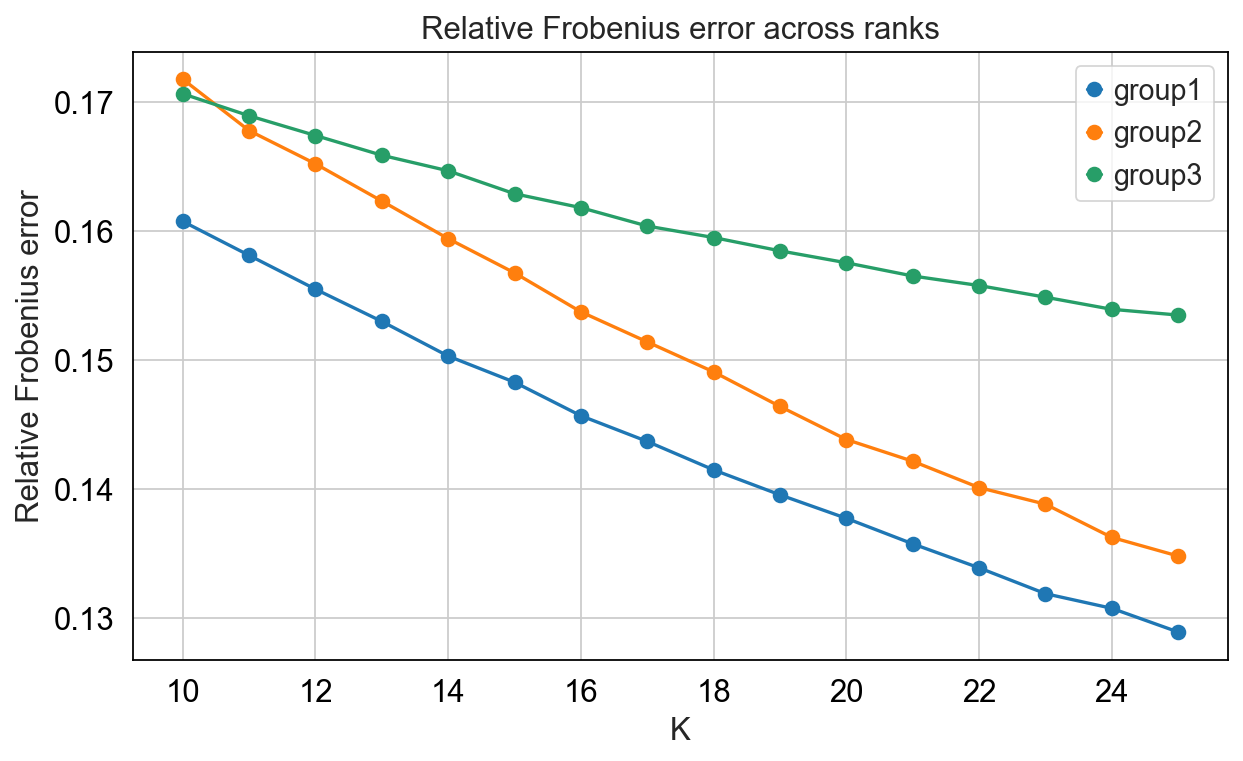

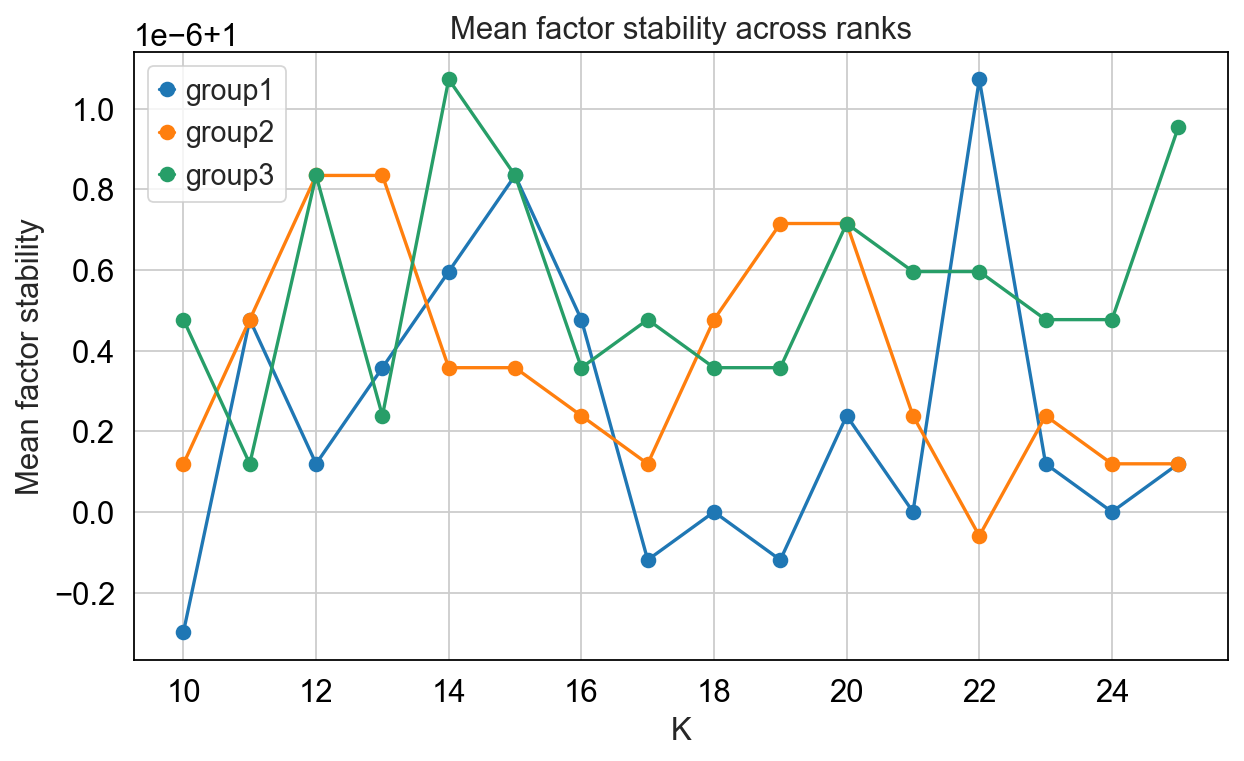

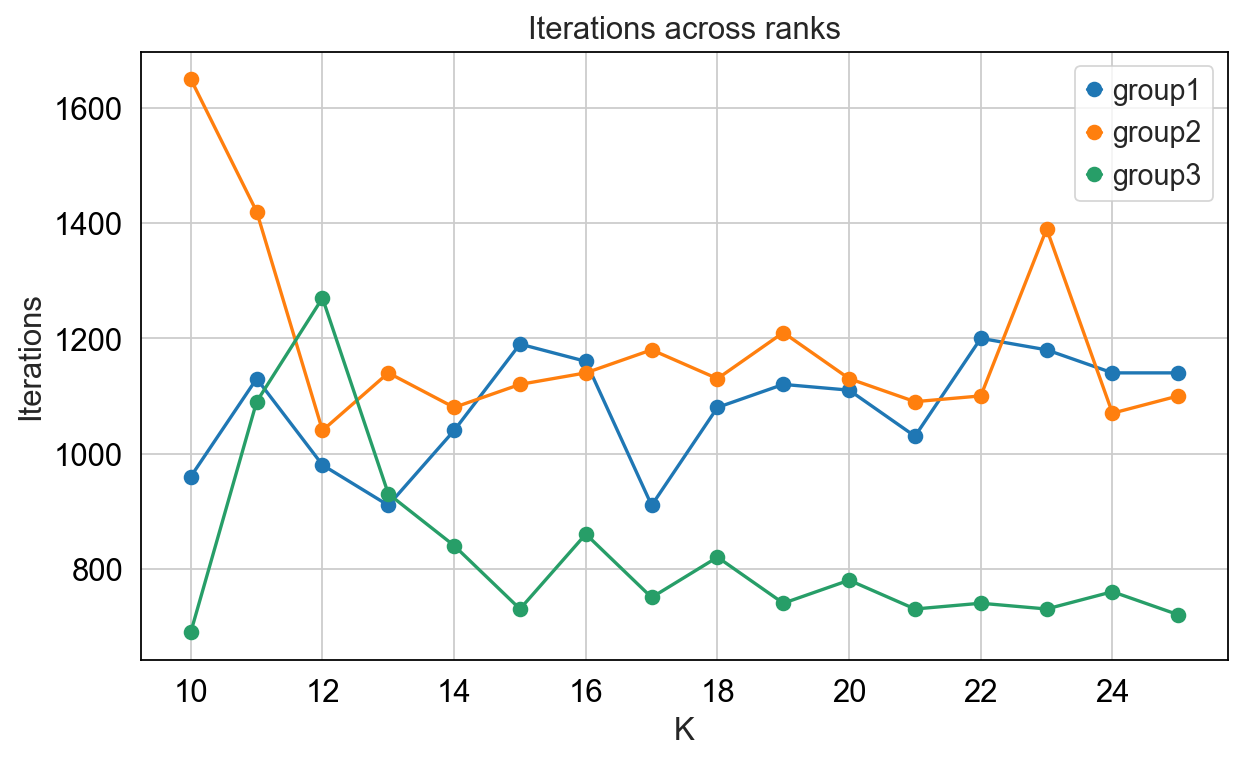

In [29]:

def load_group_summary(group_name):
    file = OUTPUT_DIR / group_name / f"{group_name}_K10_K25_summary.tsv"
    return pd.read_csv(file, sep="	")

all_summary = pd.concat(
    [load_group_summary("group1"), load_group_summary("group2"), load_group_summary("group3")],
    ignore_index=True,
)
display(all_summary)

for metric, ylabel in [
    ("relative_frobenius_error", "Relative Frobenius error"),
    ("mean_factor_similarity_to_best_loss", "Mean factor stability"),
    ("n_iter", "Iterations"),
]:
    plt.figure(figsize=(8, 5))
    for group_name, table in all_summary.groupby("group"):
        plt.plot(table["K"], table[metric], marker="o", label=group_name)
    plt.xlabel("K")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} across ranks")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [30]:

def merge_group_Ascaled(group_name, k_values=K_VALUES):
    matrices = []
    for k in k_values:
        file = OUTPUT_DIR / group_name / f"k{k}" / f"{group_name}_k{k}_Ascaled.tsv"
        if not file.exists():
            raise FileNotFoundError(f"Missing: {file}")
        matrices.append(pd.read_csv(file, sep="	", index_col=0))

    merged = pd.concat(matrices, axis=1, join="inner")
    expected_factors = sum(k_values)
    if merged.shape[1] != expected_factors:
        raise ValueError(f"{group_name}: expected {expected_factors} factors, found {merged.shape[1]}")

    output_file = OUTPUT_DIR / group_name / f"{group_name}_merged_Ascaled_K10_K25.tsv"
    merged.to_csv(output_file, sep="	")
    print(group_name, merged.shape)
    print("Saved:", output_file)
    return merged

group1_merged_A = merge_group_Ascaled("group1")
group2_merged_A = merge_group_Ascaled("group2")
group3_merged_A = merge_group_Ascaled("group3")


group1 (8857, 280)
Saved: cuda_nmf_results/group1/group1_merged_Ascaled_K10_K25.tsv
group2 (8857, 280)
Saved: cuda_nmf_results/group2/group2_merged_Ascaled_K10_K25.tsv
group3 (8857, 280)
Saved: cuda_nmf_results/group3/group3_merged_Ascaled_K10_K25.tsv


In [31]:

all_merged_A = pd.concat(
    [group1_merged_A, group2_merged_A, group3_merged_A],
    axis=1,
    join="inner",
)

expected_total_factors = 3 * sum(K_VALUES)
print("Final matrix:", all_merged_A.shape)
print("Expected factors:", expected_total_factors)

if all_merged_A.shape[1] != expected_total_factors:
    raise ValueError("最终 factor 数不正确；请检查是否缺少某个 K 的结果。")

all_merged_file = OUTPUT_DIR / "all_groups_merged_Ascaled_K10_K25.tsv"
all_merged_A.to_csv(all_merged_file, sep="	")
print("Saved:", all_merged_file.resolve())


Final matrix: (8857, 840)
Expected factors: 840
Saved: /mnt/d/HCC_ICB/cuda_nmf_results/all_groups_merged_Ascaled_K10_K25.tsv


In [32]:
factor_by_gene = all_merged_A.T
factor_by_gene_file = OUTPUT_DIR / "all_groups_factor_by_gene_K10_K25.tsv"
factor_by_gene.to_csv(factor_by_gene_file, sep="	")
print("Factor × gene:", factor_by_gene.shape)
print("Saved:", factor_by_gene_file.resolve())

Factor × gene: (840, 8857)
Saved: /mnt/d/HCC_ICB/cuda_nmf_results/all_groups_factor_by_gene_K10_K25.tsv
